In [ ]:
# =========================================
# UAV AUTOPILOT PROJECT - CLEAN NOTEBOOK
# Cell 1: Libraries
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)

In [ ]:
# =========================================
# Cell 2: Parameters
# =========================================
dt = 0.01
T_end = 10.0
t = np.arange(0, T_end + dt, dt)

theta_ref = np.deg2rad(10.0)

# Tuned controller for realistic saturated case
Kp = 1.2
Ki = 0.0
Kd = 0.7
N_filter = 10.0

# Complementary filter
alpha = 0.99

# Sensor parameters
gyro_noise_std = 0.005
gyro_bias = 0.001
accel_noise_std = 0.02

# Actuator saturation
u_min = -0.5
u_max = 0.5
du_max = 1.0

# Requirement limits
REQ_OVERSHOOT = 5.0
REQ_SETTLING = 5.0
REQ_SSE = 0.01
REQ_RISE = 2.0

print("Parameters loaded successfully.")
print(f"Kp={Kp}, Ki={Ki}, Kd={Kd}, alpha={alpha}, u_max={u_max}, du_max={du_max}")

Parameters loaded successfully.
Kp=1.2, Ki=0.0, Kd=0.7, alpha=0.99, u_max=0.5, du_max=1.0


In [ ]:
# =========================================
# Cell 3: Plant and Filter Functions
# =========================================
def plant_step(theta, q, u, dt):
    theta_ddot = u - q
    q_new = q + theta_ddot * dt
    theta_new = theta + q_new * dt
    return theta_new, q_new

def complementary_filter(theta_est_prev, gyro_meas, accel_meas, alpha, dt):
    return alpha * (theta_est_prev + gyro_meas * dt) + (1 - alpha) * accel_meas


def actuator_with_rate_limit(u_cmd, u_prev, dt, u_min, u_max, du_max):
    u_clipped = np.clip(u_cmd, u_min, u_max)
    du = u_clipped - u_prev
    du_limited = np.clip(du, -du_max * dt, du_max * dt)
    return u_prev + du_limited

In [ ]:
# =========================================
# Cell 4: Simulation Function
# =========================================
def simulate_case(feedback_mode="filtered", anti_windup=True, seed=42):
    np.random.seed(seed)
    n = len(t)
    theta_true = np.zeros(n)
    q_true = np.zeros(n)
    theta_acc = np.zeros(n)
    gyro_meas = np.zeros(n)
    theta_gyro = np.zeros(n)
    theta_filt = np.zeros(n)
    theta_fb = np.zeros(n)
    error = np.zeros(n)
    u_raw = np.zeros(n)
    u_sat = np.zeros(n)
    integral = 0.0
    d_state = 0.0

    for k in range(1, n):
        theta_acc[k] = theta_true[k-1] + np.random.normal(0, accel_noise_std)
        gyro_meas[k] = q_true[k-1] + gyro_bias + np.random.normal(0, gyro_noise_std)
        theta_gyro[k] = theta_gyro[k-1] + gyro_meas[k] * dt
        theta_filt[k] = complementary_filter(
            theta_filt[k-1], gyro_meas[k], theta_acc[k], alpha, dt
        )

        if feedback_mode == "ideal":
            theta_fb[k] = theta_true[k-1]
        elif feedback_mode == "raw_accel":
            theta_fb[k] = theta_acc[k]
        elif feedback_mode == "gyro_only":
            theta_fb[k] = theta_gyro[k]
        elif feedback_mode == "filtered":
            theta_fb[k] = theta_filt[k]
        else:
            raise ValueError("feedback_mode must be ideal, raw_accel, gyro_only, or filtered")

        error[k] = theta_ref - theta_fb[k]
        e_dot_approx = (error[k] - error[k-1]) / dt
        d_state = ((N_filter * dt) / (1 + N_filter * dt)) * e_dot_approx + \
                  (1 / (1 + N_filter * dt)) * d_state
        integral_candidate = integral + error[k] * dt
        u_unsat = Kp * error[k] + Ki * integral_candidate + Kd * d_state
        u_limited = actuator_with_rate_limit(
            u_unsat, u_sat[k-1], dt, u_min, u_max, du_max
        )

        if anti_windup:
            # Conditional integration: only update integral if NOT saturated
            if u_unsat == u_limited:
                integral = integral_candidate
        else:
            # No anti-windup: always update integral (allows windup)
            integral = integral_candidate

        u_unsat = Kp * error[k] + Ki * integral + Kd * d_state
        u_limited = actuator_with_rate_limit(
            u_unsat, u_sat[k-1], dt, u_min, u_max, du_max
        )
        u_raw[k] = u_unsat
        u_sat[k] = u_limited
        theta_true[k], q_true[k] = plant_step(
            theta_true[k-1], q_true[k-1], u_limited, dt
        )

    return {
        "t": t,
        "theta_true": theta_true,
        "q_true": q_true,
        "theta_acc": theta_acc,
        "gyro_meas": gyro_meas,
        "theta_gyro": theta_gyro,
        "theta_filt": theta_filt,
        "theta_fb": theta_fb,
        "error": error,
        "u_raw": u_raw,
        "u_sat": u_sat,
        "theta_ref": np.ones_like(t) * theta_ref
    }

In [ ]:
# =========================================
# Cell 5: Metrics and Verification
# =========================================
def compute_metrics(t, y, ref, tol=0.02):
    final_value = y[-1]
    ref_value = ref[-1]

    peak = np.max(y)
    overshoot = max(0.0, (peak - ref_value) / ref_value * 100.0)

    y10 = 0.1 * ref_value
    y90 = 0.9 * ref_value

    idx10 = np.where(y >= y10)[0]
    idx90 = np.where(y >= y90)[0]

    rise_time = np.nan
    if len(idx10) > 0 and len(idx90) > 0:
        rise_time = t[idx90[0]] - t[idx10[0]]

    band = tol * abs(ref_value)
    settling_time = np.nan
    for k in range(len(y)):
        if np.all(np.abs(y[k:] - ref_value) <= band):
            settling_time = t[k]
            break

    steady_state_error = abs(ref_value - final_value)

    return {
        "Overshoot (%)": overshoot,
        "Settling Time (s)": settling_time,
        "Steady-State Error (rad)": steady_state_error,
        "Rise Time (s)": rise_time
    }

def verify_requirements(metrics):
    rows = [
        ["REQ-01", "Overshoot", "< 5%", metrics["Overshoot (%)"], "PASS" if metrics["Overshoot (%)"] < REQ_OVERSHOOT else "FAIL"],
        ["REQ-02", "Settling time", "< 5 s", metrics["Settling Time (s)"], "PASS" if metrics["Settling Time (s)"] < REQ_SETTLING else "FAIL"],
        ["REQ-03", "Steady-state error", "< 0.01 rad", metrics["Steady-State Error (rad)"], "PASS" if metrics["Steady-State Error (rad)"] < REQ_SSE else "FAIL"],
        ["REQ-04", "Rise time", "< 2 s", metrics["Rise Time (s)"], "PASS" if metrics["Rise Time (s)"] < REQ_RISE else "FAIL"],
    ]
    return pd.DataFrame(rows, columns=["Requirement ID", "Description", "Limit", "Measured", "Status"])

In [ ]:
# =========================================
# Cell 6: Run Four Cases
# =========================================
cases = {
    "Ideal": simulate_case(feedback_mode="ideal", anti_windup=True, seed=42),
    "Raw Accelerometer": simulate_case(feedback_mode="raw_accel", anti_windup=True, seed=42),
    "Gyro Only": simulate_case(feedback_mode="gyro_only", anti_windup=True, seed=42),
    "Filtered": simulate_case(feedback_mode="filtered", anti_windup=True, seed=42),
}

summary_rows = []
for name, data in cases.items():
    m = compute_metrics(data["t"], data["theta_true"], data["theta_ref"])
    summary_rows.append([
        name,
        m["Overshoot (%)"],
        m["Settling Time (s)"],
        m["Steady-State Error (rad)"],
        m["Rise Time (s)"]
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Case", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"]
)

summary_df

,Case,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,Ideal,1.3484,3.35,2.4580e-05,2.14
1,Raw Accelerometer,4.6030,8.91,1.8064e-03,1.90
2,Gyro Only,0.0000,NaN,1.1582e-02,2.21
3,Filtered,0.9616,3.44,1.6185e-03,2.18


In [ ]:
# =========================================
# Cell 7: Verify Filtered Case
# =========================================
filtered_metrics = compute_metrics(
    cases["Filtered"]["t"],
    cases["Filtered"]["theta_true"],
    cases["Filtered"]["theta_ref"]
)

verification_df = verify_requirements(filtered_metrics)
verification_df

,Requirement ID,Description,Limit,Measured,Status
0,REQ-01,Overshoot,< 5%,0.9616,PASS
1,REQ-02,Settling time,< 5 s,3.4400,PASS
2,REQ-03,Steady-state error,< 0.01 rad,0.0016,PASS
3,REQ-04,Rise time,< 2 s,2.1800,FAIL


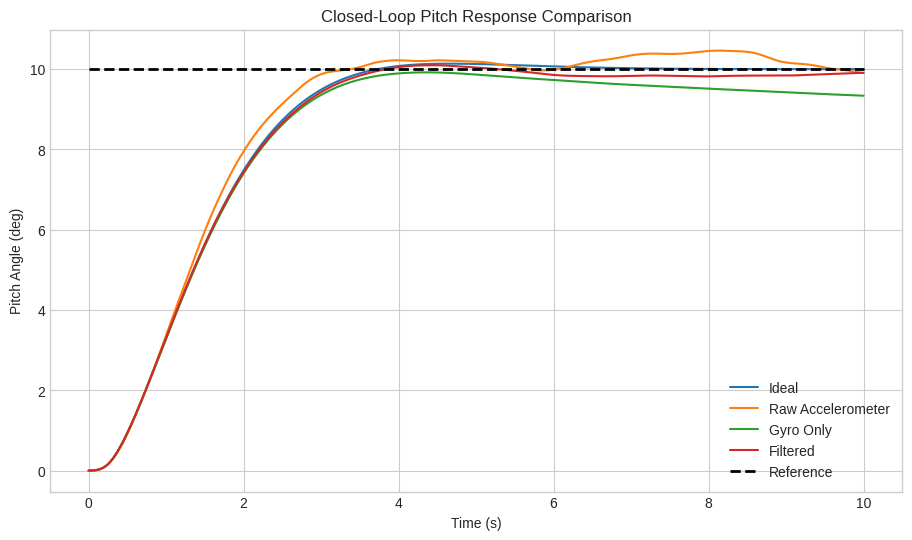

In [ ]:
# =========================================
# Cell 8: Plot Four-Case Comparison
# =========================================
plt.figure(figsize=(11, 6))
for name, data in cases.items():
    plt.plot(data["t"], np.rad2deg(data["theta_true"]), label=name)

plt.plot(cases["Filtered"]["t"], np.rad2deg(cases["Filtered"]["theta_ref"]), "k--", linewidth=2, label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Pitch Angle (deg)")
plt.title("Closed-Loop Pitch Response Comparison")
plt.legend()
plt.show()

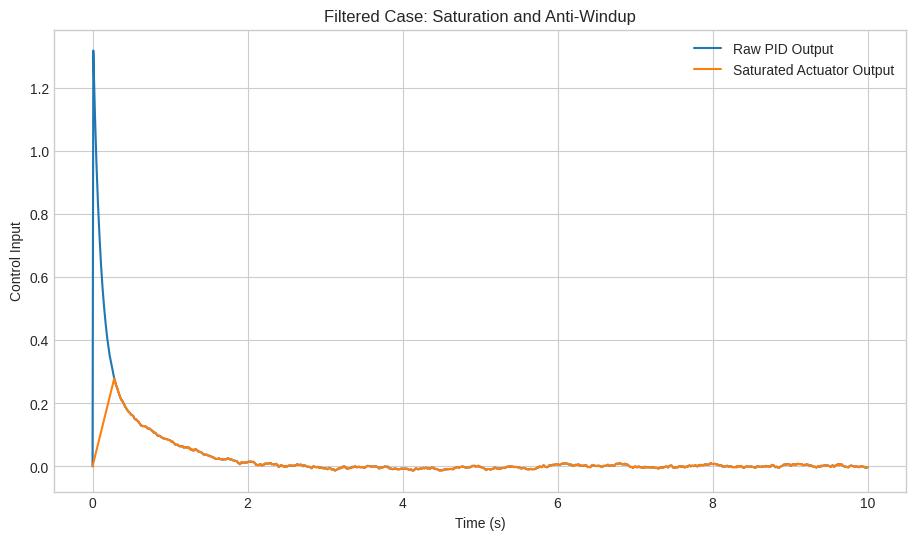

In [ ]:
# =========================================
# Cell 9: Saturation Plot
# =========================================
plt.figure(figsize=(11, 6))
plt.plot(cases["Filtered"]["t"], cases["Filtered"]["u_raw"], label="Raw PID Output")
plt.plot(cases["Filtered"]["t"], cases["Filtered"]["u_sat"], label="Saturated Actuator Output")
plt.xlabel("Time (s)")
plt.ylabel("Control Input")
plt.title("Filtered Case: Saturation and Anti-Windup")
plt.legend()
plt.show()

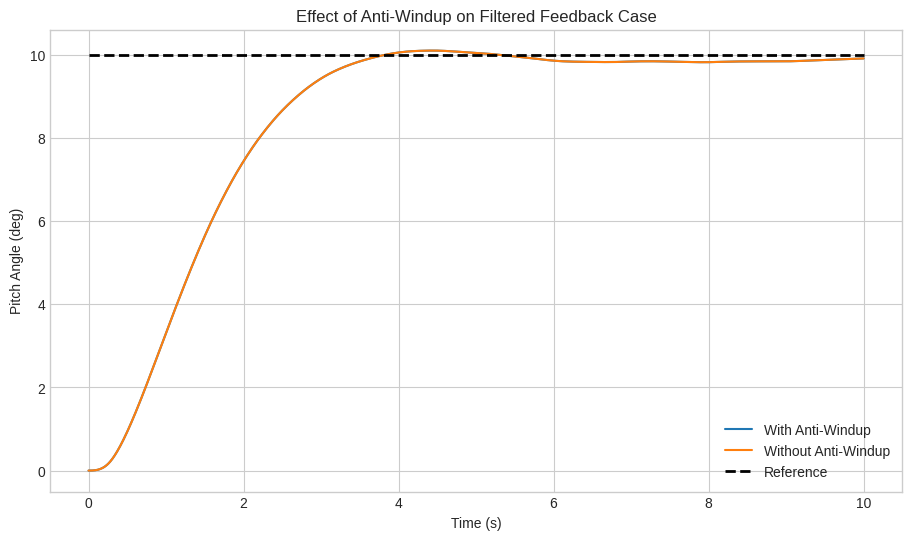

,Case,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,With Anti-Windup,0.9616,3.44,0.0016,2.18
1,Without Anti-Windup,0.9616,3.44,0.0016,2.18


In [ ]:
# =========================================
# Cell 10: Anti-Windup Comparison
# =========================================
filtered_aw = simulate_case(feedback_mode="filtered", anti_windup=True, seed=42)
filtered_no_aw = simulate_case(feedback_mode="filtered", anti_windup=False, seed=42)

plt.figure(figsize=(11, 6))
plt.plot(filtered_aw["t"], np.rad2deg(filtered_aw["theta_true"]), label="With Anti-Windup")
plt.plot(filtered_no_aw["t"], np.rad2deg(filtered_no_aw["theta_true"]), label="Without Anti-Windup")
plt.plot(filtered_aw["t"], np.rad2deg(filtered_aw["theta_ref"]), "k--", linewidth=2, label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Pitch Angle (deg)")
plt.title("Effect of Anti-Windup on Filtered Feedback Case")
plt.legend()
plt.show()

aw_metrics = compute_metrics(filtered_aw["t"], filtered_aw["theta_true"], filtered_aw["theta_ref"])
no_aw_metrics = compute_metrics(filtered_no_aw["t"], filtered_no_aw["theta_true"], filtered_no_aw["theta_ref"])

pd.DataFrame([
    ["With Anti-Windup", aw_metrics["Overshoot (%)"], aw_metrics["Settling Time (s)"], aw_metrics["Steady-State Error (rad)"], aw_metrics["Rise Time (s)"]],
    ["Without Anti-Windup", no_aw_metrics["Overshoot (%)"], no_aw_metrics["Settling Time (s)"], no_aw_metrics["Steady-State Error (rad)"], no_aw_metrics["Rise Time (s)"]],
], columns=["Case", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"])

,Kp,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,0.8,0.0000,7.15,0.0019,3.03
1,0.9,0.0000,6.46,0.0017,2.62
2,1.0,0.0000,3.71,0.0017,2.31
3,1.1,0.6470,3.21,0.0017,2.07
4,1.2,1.5121,2.84,0.0016,1.87
5,1.3,2.2120,6.92,0.0016,1.72
6,1.4,2.9720,7.05,0.0015,1.60
7,1.5,3.9097,7.13,0.0014,1.49
8,1.6,4.8002,7.15,0.0014,1.40


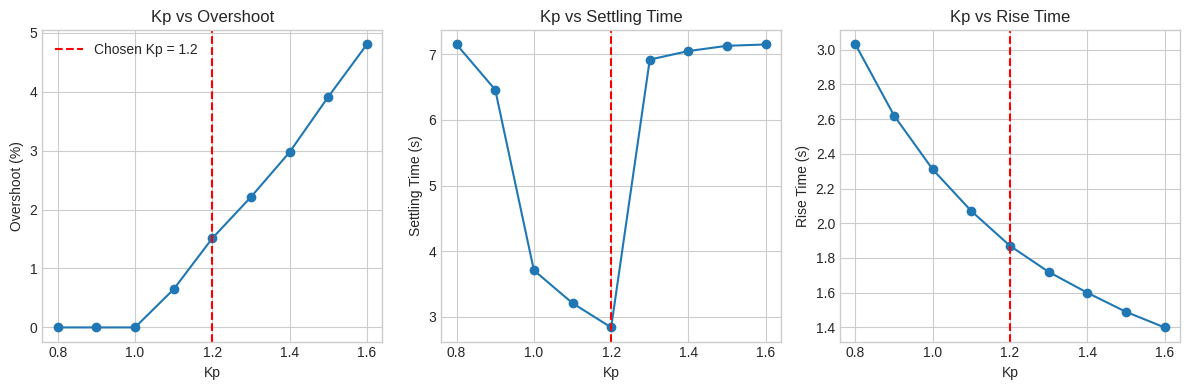

In [ ]:
# =========================================
# NEW CELL: Tuning Justification - Kp Sweep
# =========================================

def simulate_case_with_gains(Kp_test, Ki_test, Kd_test, feedback_mode="filtered", anti_windup=True, seed=42):
    np.random.seed(seed)

    n = len(t)

    theta_true = np.zeros(n)
    q_true = np.zeros(n)

    theta_acc = np.zeros(n)
    gyro_meas = np.zeros(n)

    theta_gyro = np.zeros(n)
    theta_filt = np.zeros(n)
    theta_fb = np.zeros(n)

    error = np.zeros(n)
    u_raw = np.zeros(n)
    u_sat = np.zeros(n)

    integral = 0.0
    d_state = 0.0

    for k in range(1, n):
        theta_acc[k] = theta_true[k-1] + np.random.normal(0, accel_noise_std)
        gyro_meas[k] = q_true[k-1] + gyro_bias + np.random.normal(0, gyro_noise_std)

        theta_gyro[k] = theta_gyro[k-1] + gyro_meas[k] * dt
        theta_filt[k] = complementary_filter(theta_filt[k-1], gyro_meas[k], theta_acc[k], alpha, dt)

        if feedback_mode == "ideal":
            theta_fb[k] = theta_true[k-1]
        elif feedback_mode == "raw_accel":
            theta_fb[k] = theta_acc[k]
        elif feedback_mode == "gyro_only":
            theta_fb[k] = theta_gyro[k]
        elif feedback_mode == "filtered":
            theta_fb[k] = theta_filt[k]

        error[k] = theta_ref - theta_fb[k]

        e_dot_approx = (error[k] - error[k-1]) / dt
        d_state = ((N_filter * dt) / (1 + N_filter * dt)) * e_dot_approx + (1 / (1 + N_filter * dt)) * d_state

        integral_candidate = integral + error[k] * dt
        u_unsat = Kp_test * error[k] + Ki_test * integral_candidate + Kd_test * d_state
        u_limited = np.clip(u_unsat, u_min, u_max)

        if anti_windup:
            if (u_unsat == u_limited) or ((u_unsat > u_max) and (error[k] < 0)) or ((u_unsat < u_min) and (error[k] > 0)):
                integral = integral_candidate
        else:
            integral = integral_candidate

        u_unsat = Kp_test * error[k] + Ki_test * integral + Kd_test * d_state
        u_limited = np.clip(u_unsat, u_min, u_max)

        u_raw[k] = u_unsat
        u_sat[k] = u_limited

        theta_true[k], q_true[k] = plant_step(theta_true[k-1], q_true[k-1], u_limited, dt)

    return {
        "t": t,
        "theta_true": theta_true,
        "theta_ref": np.ones_like(t) * theta_ref
    }


kp_values = np.linspace(0.8, 1.6, 9)
tuning_rows = []

for kp_test in kp_values:
    sim = simulate_case_with_gains(kp_test, Ki, Kd, feedback_mode="filtered", anti_windup=True, seed=42)
    m = compute_metrics(sim["t"], sim["theta_true"], sim["theta_ref"])
    tuning_rows.append([
        kp_test,
        m["Overshoot (%)"],
        m["Settling Time (s)"],
        m["Steady-State Error (rad)"],
        m["Rise Time (s)"]
    ])

tuning_df = pd.DataFrame(
    tuning_rows,
    columns=["Kp", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"]
)

display(tuning_df)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(tuning_df["Kp"], tuning_df["Overshoot (%)"], marker='o')
plt.axvline(Kp, color='r', linestyle='--', label=f'Chosen Kp = {Kp}')
plt.xlabel("Kp")
plt.ylabel("Overshoot (%)")
plt.title("Kp vs Overshoot")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(tuning_df["Kp"], tuning_df["Settling Time (s)"], marker='o')
plt.axvline(Kp, color='r', linestyle='--')
plt.xlabel("Kp")
plt.ylabel("Settling Time (s)")
plt.title("Kp vs Settling Time")

plt.subplot(1, 3, 3)
plt.plot(tuning_df["Kp"], tuning_df["Rise Time (s)"], marker='o')
plt.axvline(Kp, color='r', linestyle='--')
plt.xlabel("Kp")
plt.ylabel("Rise Time (s)")
plt.title("Kp vs Rise Time")

plt.tight_layout()
plt.show()

,Seed,Overshoot (%),Settling Time (s),Steady-State Error (rad),Rise Time (s)
0,0,2.2501,4.95,0.0003,2.11
1,1,0.7145,3.50,0.0020,2.20
2,2,1.3927,3.42,0.0021,2.17
3,3,1.6397,3.49,0.0009,2.18
4,4,0.0000,3.73,0.0005,2.24


,Metric,Mean,Std Dev,Min,Max
0,Overshoot (%),0.8325,0.5282,0.0000e+00,2.2993
1,Settling Time (s),3.5797,0.5936,3.2800e+00,7.9400
2,Steady-State Error (rad),0.0012,0.0009,1.0171e-05,0.0035
3,Rise Time (s),2.1640,0.0366,2.0900e+00,2.2800


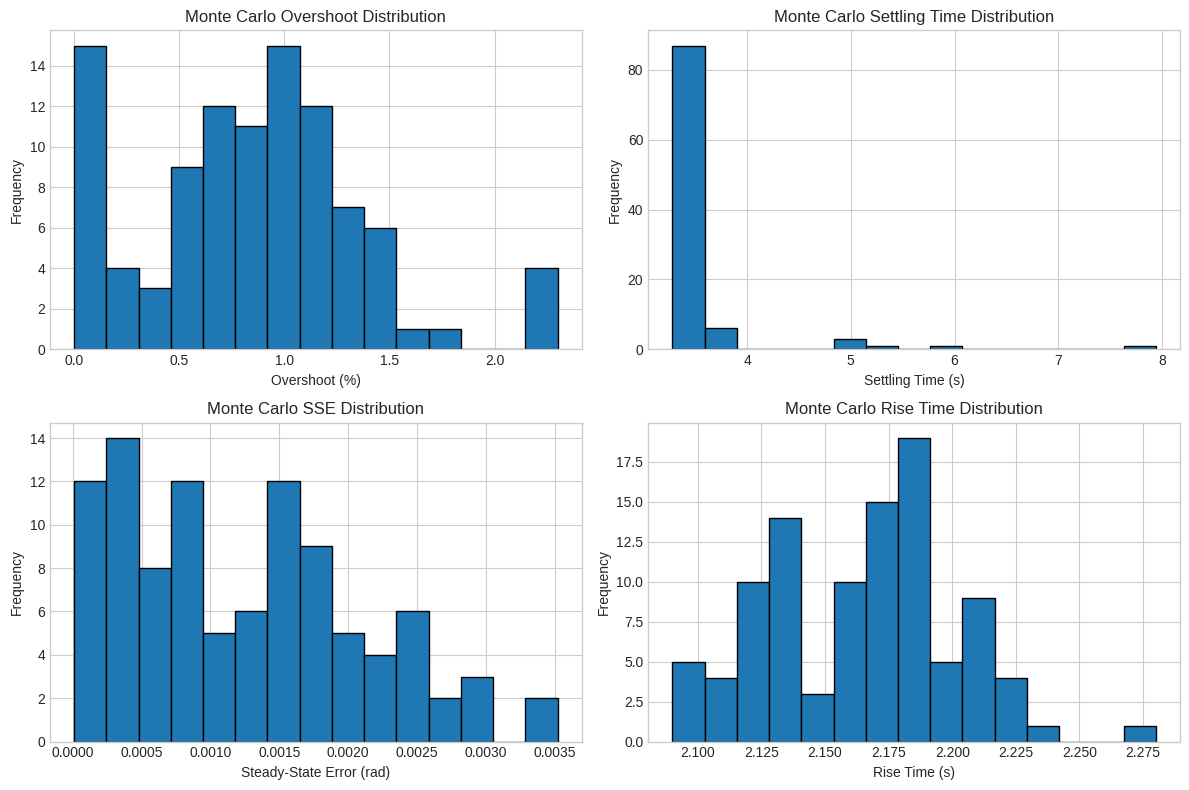

In [ ]:
# =========================================
# NEW CELL: Monte Carlo Robustness Analysis
# =========================================

num_trials = 100
mc_rows = []

for seed in range(num_trials):
    sim = simulate_case(feedback_mode="filtered", anti_windup=True, seed=seed)
    m = compute_metrics(sim["t"], sim["theta_true"], sim["theta_ref"])

    mc_rows.append([
        seed,
        m["Overshoot (%)"],
        m["Settling Time (s)"],
        m["Steady-State Error (rad)"],
        m["Rise Time (s)"]
    ])

mc_df = pd.DataFrame(
    mc_rows,
    columns=["Seed", "Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"]
)

display(mc_df.head())

mc_summary = pd.DataFrame({
    "Metric": ["Overshoot (%)", "Settling Time (s)", "Steady-State Error (rad)", "Rise Time (s)"],
    "Mean": [
        mc_df["Overshoot (%)"].mean(),
        mc_df["Settling Time (s)"].mean(),
        mc_df["Steady-State Error (rad)"].mean(),
        mc_df["Rise Time (s)"].mean()
    ],
    "Std Dev": [
        mc_df["Overshoot (%)"].std(),
        mc_df["Settling Time (s)"].std(),
        mc_df["Steady-State Error (rad)"].std(),
        mc_df["Rise Time (s)"].std()
    ],
    "Min": [
        mc_df["Overshoot (%)"].min(),
        mc_df["Settling Time (s)"].min(),
        mc_df["Steady-State Error (rad)"].min(),
        mc_df["Rise Time (s)"].min()
    ],
    "Max": [
        mc_df["Overshoot (%)"].max(),
        mc_df["Settling Time (s)"].max(),
        mc_df["Steady-State Error (rad)"].max(),
        mc_df["Rise Time (s)"].max()
    ]
})

display(mc_summary)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(mc_df["Overshoot (%)"], bins=15, edgecolor='black')
plt.xlabel("Overshoot (%)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Overshoot Distribution")

plt.subplot(2, 2, 2)
plt.hist(mc_df["Settling Time (s)"].dropna(), bins=15, edgecolor='black')
plt.xlabel("Settling Time (s)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Settling Time Distribution")

plt.subplot(2, 2, 3)
plt.hist(mc_df["Steady-State Error (rad)"], bins=15, edgecolor='black')
plt.xlabel("Steady-State Error (rad)")
plt.ylabel("Frequency")
plt.title("Monte Carlo SSE Distribution")

plt.subplot(2, 2, 4)
plt.hist(mc_df["Rise Time (s)"], bins=15, edgecolor='black')
plt.xlabel("Rise Time (s)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Rise Time Distribution")

plt.tight_layout()
plt.show()